In [1]:
# If you are using colab:
#!pip install scikit-fmm

Step0: Generate toy binary shape and continous mask

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

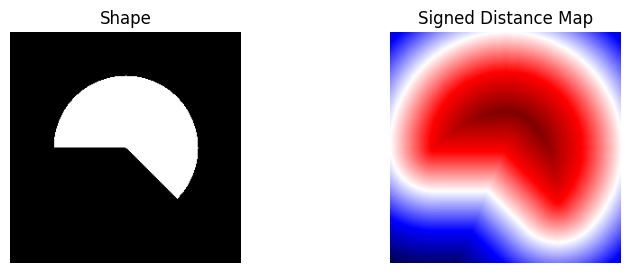

In [2]:
from numpy.ma.core import ones
import numpy as np
import skfmm
import torch
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from IPython.display import clear_output
from PIL import Image
import cv2
from math import ceil, sqrt
from IPython.display import clear_output
from loss import C2nd_loss, C1st_loss, fidelity_loss

def make_circle(shape=(128,128), center=(128,128), radius=30):
    img = np.zeros(shape, np.uint8)
    cv2.circle(img, center, radius, 255, -1)
    return img

# Parameters
H, W = 256, 256
center = (H // 2, W // 2)
radius = 80

# Initial binary shape: circle with missing sector
Y, X = np.ogrid[:H, :W]
dist_from_center = np.sqrt((X - center[1]) ** 2 + (Y - center[0]) ** 2)
mask = dist_from_center <= radius
angle = np.arctan2(Y - center[0], X - center[1]) * 180 / np.pi
mask[(angle >= 45) & (angle <= 180)] = 0

# Alternatively, you can upload an image to create shapes.
# For the toy figure, (objects.png)
# set both convexity loss weights to 0.1
#img = Image.open("Toyshapes/objects.png").convert("L")
#img_array = np.array(img)
#img_array = cv2.resize(img_array, (512, 512), interpolation=cv2.INTER_LINEAR)
#mask = img_array < 128

# Signed distance function via scikit-fmm
phi = np.where(mask, 1.0, -1.0)
sdf = skfmm.distance(phi)

# Normalize to [-1, 1]
max_abs_sdf = np.max(np.abs(sdf))
if max_abs_sdf > 0:
  sdf = sdf / max_abs_sdf

#
sdf_orig_tensor = torch.tensor(sdf, dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # [1, 1, H, W]

# Plot
fig, axs = plt.subplots(1, 2, figsize=(9, 3))
axs[0].imshow(mask, cmap='gray')
axs[0].set_title('Shape')
axs[0].axis('off')

axs[1].imshow(sdf, cmap='seismic')
axs[1].set_title('Signed Distance Map')
axs[1].axis('off')

Zero-order Midpoint Convexification (Algorithm 1)

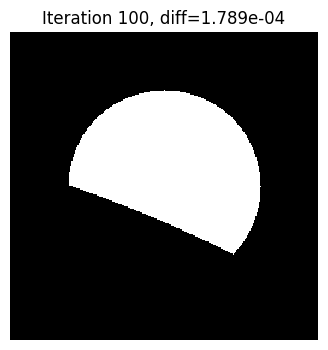

In [3]:
def _disk_offsets(radius: int) -> np.ndarray:
    rr = int(ceil(radius))
    dxs = np.arange(-rr, rr + 1)
    dys = np.arange(-rr, rr + 1)
    offs = []
    for dy in dys:
        for dx in dxs:
            if dy == 0 and dx == 0:
                continue
            if sqrt(dy*dy + dx*dx) <= radius:
                offs.append((dy, dx))
    return np.array(offs, dtype=int)

def midpoint_convexify_fast(
    u: np.ndarray,
    radius: int = 1,
    max_iters: int = 100,
    tol: float = 1e-9,
    show_plots: bool = True,
) -> np.ndarray:
    """
    Vectorized midpoint convexification.
    For each center p and offset (dy,dx) we look at:
      center = u[p]
      endpoint = u[p + 2*(dy,dx)]
      candidate = min(center, endpoint)
    and set midpoint u[p + (dy,dx)] := max(u[p + (dy,dx)], candidate)
    The implementation computes all candidates per iteration and applies the
    pointwise maximum update synchronously.

    Args:
        u: 2D float array in [0,1], shape (H, W).
        radius: integer neighborhood radius (controls offsets).
        max_iters: maximum global passes.
        tol: small tolerance for detecting change (useful for float).
        show_plots: if True, displays mask each iteration (slower).

    Returns:
        u_convexified: np.ndarray same shape and dtype as input.
    """
    if u.ndim != 2:
        raise ValueError("Input u must be a 2D array.")
    H, W = u.shape
    u = u.astype(float, copy=True)  # work on a float copy

    offsets = _disk_offsets(radius)
    if offsets.size == 0:
        return u

    max_shift = 2 * int(ceil(radius))  # padding to safely access 2*offset
    pad = max_shift
    c0, c1 = pad, pad + H
    d0, d1 = pad, pad + W

    iteration = 0
    changed = True

    while iteration < max_iters and changed:
        changed = False
        # padded copy (we'll read from this as the 'current' state)
        padded = np.pad(u, pad_width=pad, mode='constant', constant_values=0.0)
        # region where we will write candidate-updates (initialized with current values)
        updates = padded.copy()

        center = padded[c0:c1, d0:d1]  # shape (H,W)

        # accumulate candidate maxima into updates (at midpoint locations)
        for dy, dx in offsets:
            ey0 = c0 + 2*dy
            ex0 = d0 + 2*dx
            ey1 = ey0 + H
            ex1 = ex0 + W

            # endpoint slice (aligned to center when comparing)
            endpoint = padded[ey0:ey1, ex0:ex1]  # shape (H,W)

            # candidate values to write into midpoint positions:
            candidate = np.minimum(center, endpoint)  # shape (H,W)

            # midpoint target slice coordinates in padded array:
            my0 = c0 + dy
            mx0 = d0 + dx
            my1 = my0 + H
            mx1 = mx0 + W

            # apply max with existing updates at midpoint slice:
            # (this keeps the greatest candidate across all offsets)
            tgt = updates[my0:my1, mx0:mx1]
            # elementwise max
            np.maximum(tgt, candidate, out=tgt)
            # write back (tgt is a view so updates changes in-place)

        # extract the updated center region (after considering all offsets)
        new_center = updates[c0:c1, d0:d1]

        # check for change (use L-inf norm via max absolute diff)
        diff = np.max(np.abs(new_center - u))
        if diff > tol:
            changed = True
            u[:, :] = new_center  # commit whole updated center region
        else:
            changed = False

        if show_plots and (iteration+1) % 10 == 0:
            clear_output(wait=True)
            plt.figure(figsize=(4,4))
            plt.imshow((u >= 0.5), cmap='gray', vmin=0, vmax=1, interpolation='nearest')
            plt.title(f'Iteration {iteration + 1}, diff={diff:.3e}')
            plt.axis('off')
            plt.show()

        iteration += 1

    return u

#Use Sigmoid to simulate network mask output u ([0,1] probability map)
u = torch.sigmoid(sdf_orig_tensor).detach().squeeze(0).squeeze(0).numpy()  # [H, W]

# Reduce or increase radius for different behaviors.
final_mask = midpoint_convexify_fast(u, radius=15, max_iters=200)

First-order loss convexfication

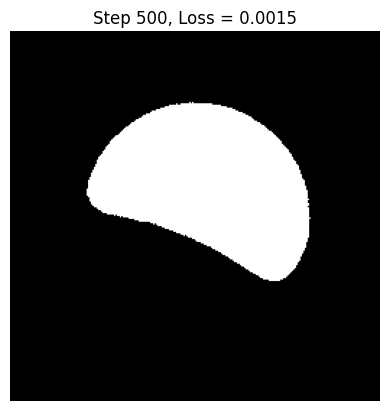

In [4]:
# Step 1: Initialize
sdf_tensor = sdf_orig_tensor.clone().detach().requires_grad_(True)
#Use Sigmoid to simulate network mask output u ([0,1] probability map)
u_orig = torch.sigmoid(sdf_orig_tensor).detach()  # [1, 1, H, W]

# Step 2: CGPM loop
steps = 500
convex_weight = 2.0
lr = 1e-2
beta1 = 0.9
beta2 = 0.999
adam_eps = 1e-8

m = torch.zeros_like(sdf_tensor)
v = torch.zeros_like(sdf_tensor)

plt.figure(figsize=(4, 4))

for step in range(1, steps + 1):

    # The following is for boundary stability. Can comment if you find unnecessay.
    with torch.no_grad():
        sdf_tensor[..., :3, :] = -1
        sdf_tensor[..., -3:, :] = -1
        sdf_tensor[..., :, -3:] = -1
        sdf_tensor[..., :, :3] = -1

    # Total loss
    u = torch.sigmoid(sdf_tensor)
    loss_fid = fidelity_loss(u, u_orig)
    loss_convex = C1st_loss(u, window_size=7)
    total_loss = loss_fid + convex_weight * loss_convex

    # Compute gradient
    grad_sdf = torch.autograd.grad(
        total_loss,
        sdf_tensor,
        create_graph=False,
        retain_graph=False,
        only_inputs=True
    )[0]

    # Adam gradient descent
    m = beta1 * m + (1.0 - beta1) * grad_sdf
    v = beta2 * v + (1.0 - beta2) * (grad_sdf * grad_sdf)

    m_hat = m / (1.0 - beta1 ** step)
    v_hat = v / (1.0 - beta2 ** step)

    with torch.no_grad():
        sdf_tensor = sdf_tensor - lr * m_hat / (torch.sqrt(v_hat) + adam_eps)

    # Make sdf_tensor differentiable again for the next iteration
    sdf_tensor = sdf_tensor.detach().requires_grad_(True)

    if step % 10 == 0:
        clear_output(wait=True)

        with torch.no_grad():
            u_display = torch.sigmoid(sdf_tensor)

        plt.imshow(
            (u_display >= 0.5).squeeze().detach().cpu().numpy(),
            cmap="gray"
        )
        plt.title(f"Step {step}, Loss = {total_loss.item():.4f}")
        plt.axis("off")
        plt.show()

Second-order loss convexfication

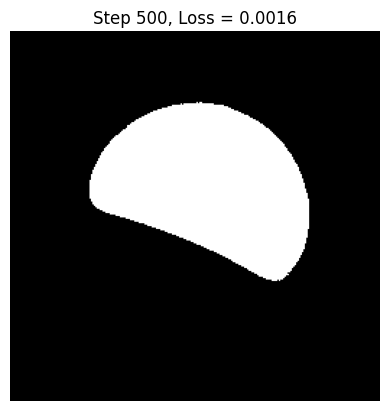

In [5]:
# Step 1: Initialize
sdf_tensor = sdf_orig_tensor.clone().detach().requires_grad_(True)
#Use Sigmoid to simulate network mask output u ([0,1] probability map)
u_orig = torch.sigmoid(sdf_orig_tensor).detach()  # [1, 1, H, W]

# Step 2: CGPM loop
steps = 500
convex_weight = 0.5
lr = 1e-2
beta1 = 0.9
beta2 = 0.999
adam_eps = 1e-8

m = torch.zeros_like(sdf_tensor)
v = torch.zeros_like(sdf_tensor)

plt.figure(figsize=(4, 4))

for step in range(1, steps + 1):

    # The following is for boundary stability. Can comment if you find unnecessay.
    with torch.no_grad():
        sdf_tensor[..., :3, :] = -1
        sdf_tensor[..., -3:, :] = -1
        sdf_tensor[..., :, -3:] = -1
        sdf_tensor[..., :, :3] = -1

    # Total loss
    u = torch.sigmoid(sdf_tensor)
    loss_fid = fidelity_loss(u, u_orig)
    loss_convex = C2nd_loss(u)
    total_loss = loss_fid + convex_weight * loss_convex

    # Compute gradient
    grad_sdf = torch.autograd.grad(
        total_loss,
        sdf_tensor,
        create_graph=False,
        retain_graph=False,
        only_inputs=True
    )[0]

    # Adam gradient descent
    m = beta1 * m + (1.0 - beta1) * grad_sdf
    v = beta2 * v + (1.0 - beta2) * (grad_sdf * grad_sdf)

    m_hat = m / (1.0 - beta1 ** step)
    v_hat = v / (1.0 - beta2 ** step)

    with torch.no_grad():
        sdf_tensor = sdf_tensor - lr * m_hat / (torch.sqrt(v_hat) + adam_eps)

    # Make sdf_tensor differentiable again for the next iteration
    sdf_tensor = sdf_tensor.detach().requires_grad_(True)

    if step % 50 == 0:
        clear_output(wait=True)

        with torch.no_grad():
            u_display = torch.sigmoid(sdf_tensor)

        plt.imshow(
            (u_display >= 0.5).squeeze().detach().cpu().numpy(),
            cmap="gray"
        )
        plt.title(f"Step {step}, Loss = {total_loss.item():.4f}")
        plt.axis("off")
        plt.show()